# Logistic Regression Experiments

This notebook documents all logistic regression experiments on the fraud detection dataset.
Each experiment builds on the previous one to systematically find the best configuration.

**Feature sets tested:**
- **Partially Selected (PS):** All 37 features after data preparation (minus dropped columns)
- **Selected / MRMR:** 17 features chosen by MRMR feature selection

**Experiments:**
1. Baseline (L2, C=1.0, balanced)
2. Cross-validation stability
3. C parameter tuning
4. Best C with CV confirmation
5. Threshold tuning
6. L1 regularization (Lasso)
7. Elastic Net (L1 + L2 mix)
8. Regularization coefficient comparison
9. No class weighting (ablation)
10. SMOTE comparison
11. Run summary & model selection
12. Final test evaluation

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.data.load_data import load_selected_features
from src.data.preprocess import encode_target, split_data
from src.models.predict import predict, predict_proba
from src.evaluation.metrics import evaluate_model, print_metrics

print('Imports loaded successfully.')

Imports loaded successfully.


## Data Preparation

We load both feature sets and apply the same preprocessing pipeline:
1. **One-hot encoding** for categorical features (fit on train only, aligned to val/test)
2. **Standard scaling** for all features (fit on train only)
3. **Stratified 70/15/15 split** — train/validation/test

In [2]:
def prepare_dataset(path, label):
    df = load_selected_features(path)
    print(f"\n{'='*60}")
    print(f"{label} -- {path}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print(f"Class distribution:\n{df['fraud_reported'].value_counts()}")
    print(f"Fraud rate: {(df['fraud_reported'] == 'Y').mean()*100:.1f}%")

    X = df.drop(columns=['fraud_reported'])
    y = encode_target(df['fraud_reported'])

    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical features ({len(num_cols)}): {num_cols}")

    # Split BEFORE encoding
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, test_size=0.15, val_size=0.15, random_state=42
    )

    # One-hot encode: fit on train, align val/test
    X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
    train_cols = X_train.columns

    X_val = pd.get_dummies(X_val, columns=cat_cols, drop_first=False)
    X_val = X_val.reindex(columns=train_cols, fill_value=0)

    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)

    # Standard scaling: fit on train only
    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=train_cols, index=X_train.index)
    X_val_s = pd.DataFrame(scaler.transform(X_val), columns=train_cols, index=X_val.index)
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=train_cols, index=X_test.index)

    print(f"\nAfter one-hot encoding: {X_train.shape[1]} features")
    print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

    return {
        'X_train': X_train_s, 'X_val': X_val_s, 'X_test': X_test_s,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'scaler': scaler, 'label': label, 'train_cols': train_cols.tolist(),
    }

ds_ps = prepare_dataset('../data/processed/partially_selected_features.csv', 'Partially Selected (PS)')
ds_s  = prepare_dataset('../data/processed/selected_features.csv', 'Selected / MRMR')

datasets = [ds_ps, ds_s]


Partially Selected (PS) -- ../data/processed/partially_selected_features.csv
Shape: (1000, 37)
Class distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64
Fraud rate: 24.7%

Categorical features (17): ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']
Numerical features (19): ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'policy_tenure_days', 'incident_day_of_week', 'incident_month']

After one-hot encoding: 162 features
Train: 700  |  Val: 1

---
## Run 1: Baseline Logistic Regression

**Goal:** Establish a baseline with default logistic regression (L2, C=1.0, balanced class weights).

**Why balanced?** The dataset is imbalanced (~75% non-fraud, ~25% fraud). `class_weight='balanced'`
automatically adjusts weights inversely proportional to class frequencies.

In [3]:
for ds in datasets:
    model = LogisticRegression(
        C=1.0, penalty='l2', solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=42
    )
    model.fit(ds['X_train'], ds['y_train'])
    ds['model_v1'] = model
    ds['results_log'] = []

    y_prob_val = predict_proba(model, ds['X_val'])
    y_pred_val = predict(model, ds['X_val'])
    val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)

    y_pred_train = predict(model, ds['X_train'])
    y_prob_train = predict_proba(model, ds['X_train'])
    train_res = evaluate_model(ds['y_train'], y_pred_train, y_prob_train)

    ds['results_log'].append({
        'Run': 'V1: Baseline L2, C=1.0',
        'Train F1': train_res['f1'], 'Val F1': val_res['f1'],
        'Val Precision': val_res['precision'], 'Val Recall': val_res['recall'],
        'Val ROC AUC': val_res['roc_auc'], 'Threshold': 0.5,
    })

    print(f"\n{'='*60}")
    print(f"{ds['label']} -- Baseline LR (L2, C=1.0, balanced)")
    print(f"{'='*60}")
    print_metrics(train_res, 'Train')
    print()
    print_metrics(val_res, 'Validation')


Partially Selected (PS) -- Baseline LR (L2, C=1.0, balanced)
[Train] Accuracy:  0.9100
[Train] Precision: 0.7594
[Train] Recall:    0.9306
[Train] F1 Score:  0.8364
[Train] ROC AUC:   0.9639

[Validation] Accuracy:  0.8267
[Validation] Precision: 0.6571
[Validation] Recall:    0.6216
[Validation] F1 Score:  0.6389
[Validation] ROC AUC:   0.8560

Selected / MRMR -- Baseline LR (L2, C=1.0, balanced)
[Train] Accuracy:  0.8957
[Train] Precision: 0.7252
[Train] Recall:    0.9306
[Train] F1 Score:  0.8152
[Train] ROC AUC:   0.9573

[Validation] Accuracy:  0.8333
[Validation] Precision: 0.6579
[Validation] Recall:    0.6757
[Validation] F1 Score:  0.6667
[Validation] ROC AUC:   0.8546


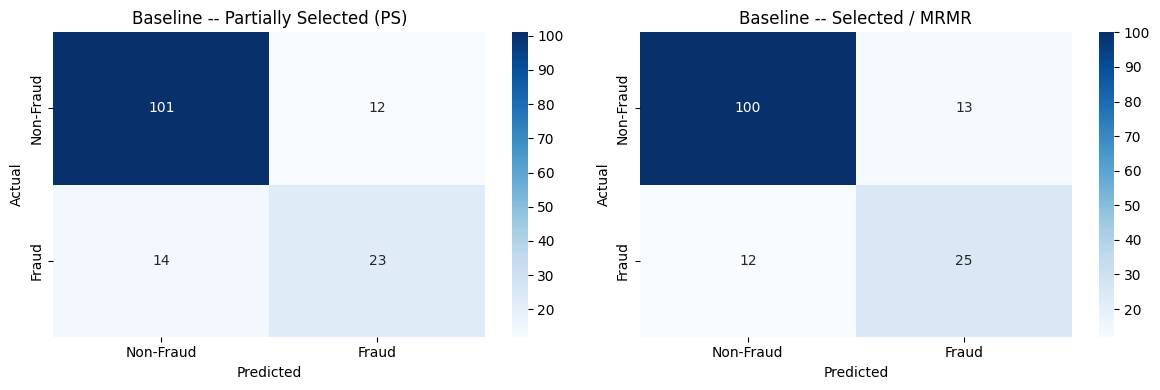

In [4]:
fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 4))
for ax, ds in zip(axes, datasets):
    y_pred = predict(ds['model_v1'], ds['X_val'])
    cm = confusion_matrix(ds['y_val'], y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    ax.set_title(f"Baseline -- {ds['label']}")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Run 2: Cross-Validation to Assess Stability

**Goal:** Assess how stable the baseline LR is across different data folds before tuning.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ds in datasets:
    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    cv_model = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000,
                                   class_weight='balanced', random_state=42)
    cv_scores = cross_val_score(cv_model, ds['X_train'], ds['y_train'], cv=cv, scoring='f1')
    print(f"CV F1 scores: {cv_scores}")
    print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    ds['results_log'].append({
        'Run': f'V2: CV baseline (mean={cv_scores.mean():.3f})',
        'Train F1': cv_scores.mean(), 'Val F1': cv_scores.mean(),
        'Val Precision': np.nan, 'Val Recall': np.nan,
        'Val ROC AUC': np.nan, 'Threshold': 0.5,
    })


Partially Selected (PS)
CV F1 scores: [0.61111111 0.68571429 0.60240964 0.46341463 0.64      ]
Mean: 0.6005 (+/- 0.0745)

Selected / MRMR
CV F1 scores: [0.66666667 0.72463768 0.65       0.57142857 0.71794872]
Mean: 0.6661 (+/- 0.0554)


---
## Run 3: Regularization Tuning (C parameter)

**Goal:** Find the optimal regularization strength.

**Why tune C?** C controls the inverse of regularization strength. Smaller C = stronger regularization
(simpler model), larger C = weaker regularization (more complex model). Finding the sweet spot
prevents both underfitting and overfitting.

In [6]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

for ds in datasets:
    c_results = []
    for C in C_values:
        model_c = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000,
                                      class_weight='balanced', random_state=42)
        model_c.fit(ds['X_train'], ds['y_train'])
        y_pred_t = predict(model_c, ds['X_train'])
        y_pred_v = predict(model_c, ds['X_val'])
        y_prob_v = predict_proba(model_c, ds['X_val'])
        c_results.append({
            'C': C,
            'Train F1': f1_score(ds['y_train'], y_pred_t),
            'Val F1': f1_score(ds['y_val'], y_pred_v),
            'Val ROC AUC': evaluate_model(ds['y_val'], y_pred_v, y_prob_v)['roc_auc'],
        })
    c_df = pd.DataFrame(c_results)
    ds['c_df'] = c_df
    best_idx = c_df['Val F1'].idxmax()
    ds['best_c'] = c_df.loc[best_idx, 'C']
    print(f"\n{ds['label']} -- Best C = {ds['best_c']} (Val F1 = {c_df.loc[best_idx, 'Val F1']:.4f})")
    print(c_df.to_string(index=False))


Partially Selected (PS) -- Best C = 0.01 (Val F1 = 0.7073)
      C  Train F1   Val F1  Val ROC AUC
  0.001  0.716346 0.681818     0.839512
  0.010  0.786070 0.707317     0.859364
  0.100  0.816327 0.666667     0.871083
  0.500  0.837209 0.638889     0.859842
  1.000  0.836364 0.638889     0.856015
  5.000  0.843750 0.619718     0.849797
 10.000  0.843750 0.619718     0.848362
 50.000  0.841558 0.619718     0.847166
100.000  0.841558 0.619718     0.846927



Selected / MRMR -- Best C = 0.01 (Val F1 = 0.7160)
      C  Train F1   Val F1  Val ROC AUC
  0.001  0.718447 0.666667     0.840230
  0.010  0.786070 0.716049     0.855059
  0.100  0.817259 0.684211     0.858407
  0.500  0.811083 0.675676     0.855776
  1.000  0.815190 0.666667     0.854580
  5.000  0.815190 0.666667     0.852188
 10.000  0.812183 0.666667     0.851232
 50.000  0.812183 0.648649     0.847644
100.000  0.812183 0.648649     0.845970


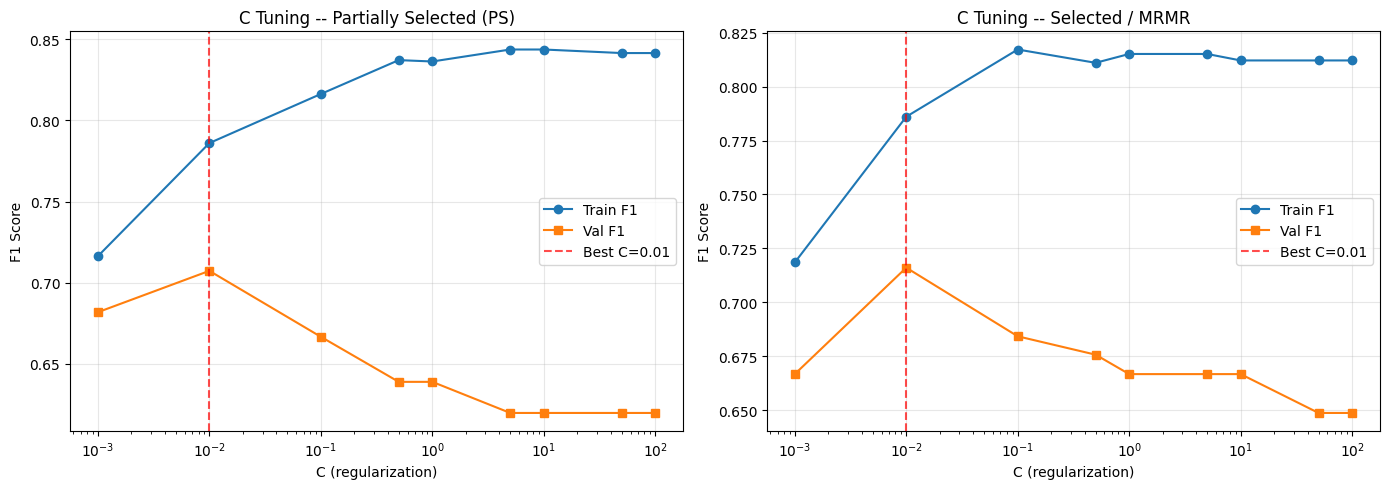

In [7]:
fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 5))
for ax, ds in zip(axes, datasets):
    c_df = ds['c_df']
    ax.semilogx(c_df['C'], c_df['Train F1'], 'o-', label='Train F1')
    ax.semilogx(c_df['C'], c_df['Val F1'], 's-', label='Val F1')
    ax.axvline(x=ds['best_c'], color='red', linestyle='--', alpha=0.7, label=f"Best C={ds['best_c']}")
    ax.set_xlabel('C (regularization)')
    ax.set_ylabel('F1 Score')
    ax.set_title(f"C Tuning -- {ds['label']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Run 4: Best C with Cross-Validation Confirmation

**Goal:** Confirm the best C found in Run 3 via cross-validation and retrain.

In [8]:
for ds in datasets:
    best_c = ds['best_c']
    model_v2 = LogisticRegression(C=best_c, penalty='l2', solver='lbfgs', max_iter=1000,
                                   class_weight='balanced', random_state=42)
    cv_scores = cross_val_score(model_v2, ds['X_train'], ds['y_train'], cv=cv, scoring='f1')
    print(f"\n{'='*60}")
    print(f"{ds['label']} -- C={best_c}")
    print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    model_v2.fit(ds['X_train'], ds['y_train'])
    ds['model_v2'] = model_v2

    y_prob_val = predict_proba(model_v2, ds['X_val'])
    y_pred_val = predict(model_v2, ds['X_val'])
    val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)
    train_res = evaluate_model(ds['y_train'], predict(model_v2, ds['X_train']),
                               predict_proba(model_v2, ds['X_train']))
    print_metrics(val_res, 'Validation')

    ds['results_log'].append({
        'Run': f'V3: L2, C={best_c}',
        'Train F1': train_res['f1'], 'Val F1': val_res['f1'],
        'Val Precision': val_res['precision'], 'Val Recall': val_res['recall'],
        'Val ROC AUC': val_res['roc_auc'], 'Threshold': 0.5,
    })


Partially Selected (PS) -- C=0.01
CV F1: 0.6980 (+/- 0.0373)
[Validation] Accuracy:  0.8400
[Validation] Precision: 0.6444
[Validation] Recall:    0.7838
[Validation] F1 Score:  0.7073
[Validation] ROC AUC:   0.8594

Selected / MRMR -- C=0.01
CV F1: 0.7173 (+/- 0.0357)
[Validation] Accuracy:  0.8467
[Validation] Precision: 0.6591
[Validation] Recall:    0.7838
[Validation] F1 Score:  0.7160
[Validation] ROC AUC:   0.8551


---
## Run 5: Threshold Tuning

**Goal:** The default classification threshold is 0.5, but this may not be optimal for imbalanced
fraud detection where we want to balance precision and recall.

In [9]:
thresholds = np.arange(0.1, 0.91, 0.05)

for ds in datasets:
    y_prob_val = predict_proba(ds['model_v2'], ds['X_val'])
    threshold_results = []
    for t in thresholds:
        y_pred_t = (y_prob_val >= t).astype(int)
        if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
            continue
        threshold_results.append({
            'Threshold': t,
            'Precision': evaluate_model(ds['y_val'], y_pred_t)['precision'],
            'Recall': evaluate_model(ds['y_val'], y_pred_t)['recall'],
            'F1': f1_score(ds['y_val'], y_pred_t),
        })
    t_df = pd.DataFrame(threshold_results)
    ds['t_df'] = t_df
    best_idx = t_df['F1'].idxmax()
    ds['best_t'] = t_df.loc[best_idx, 'Threshold']
    ds['best_threshold'] = ds['best_t']
    print(f"\n{ds['label']} -- Best threshold = {ds['best_t']:.2f} (F1 = {t_df.loc[best_idx, 'F1']:.4f})")


Partially Selected (PS) -- Best threshold = 0.55 (F1 = 0.7273)



Selected / MRMR -- Best threshold = 0.55 (F1 = 0.7273)


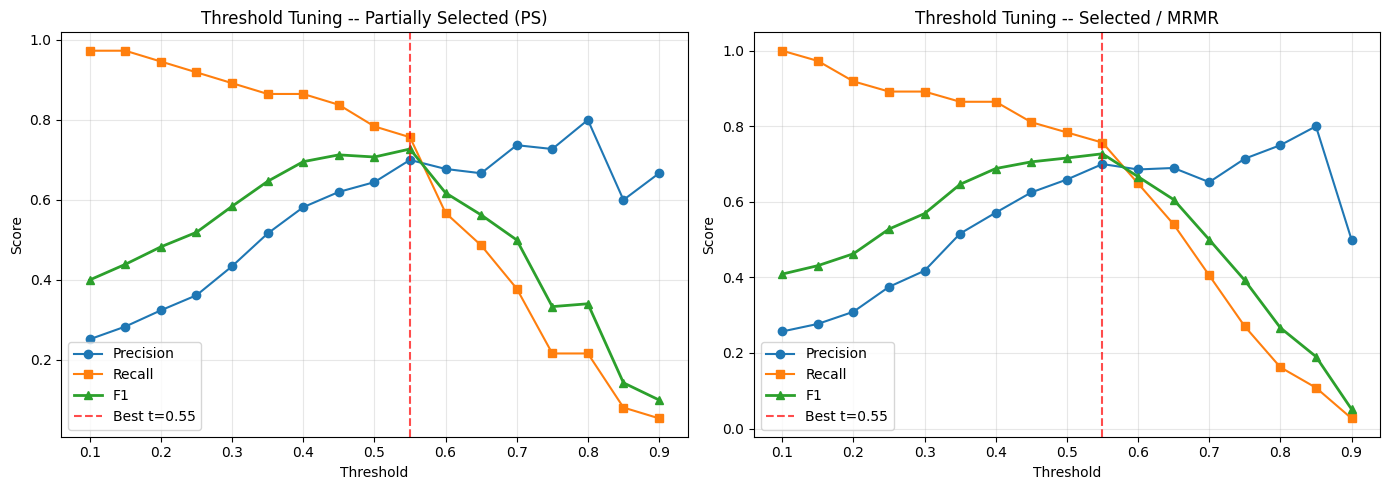

In [10]:
fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 5))
for ax, ds in zip(axes, datasets):
    t_df = ds['t_df']
    ax.plot(t_df['Threshold'], t_df['Precision'], 'o-', label='Precision')
    ax.plot(t_df['Threshold'], t_df['Recall'], 's-', label='Recall')
    ax.plot(t_df['Threshold'], t_df['F1'], '^-', label='F1', linewidth=2)
    ax.axvline(x=ds['best_t'], color='red', linestyle='--', alpha=0.7, label=f"Best t={ds['best_t']:.2f}")
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f"Threshold Tuning -- {ds['label']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
for ds in datasets:
    bt = ds['best_t']
    print(f"\n{'='*60}")
    print(f"{ds['label']} -- threshold = {bt:.2f}")
    print(f"{'='*60}")
    for name, X_set, y_set in [("Train", ds['X_train'], ds['y_train']),
                                ("Validation", ds['X_val'], ds['y_val'])]:
        y_prob = predict_proba(ds['model_v2'], X_set)
        y_pred_t = (y_prob >= bt).astype(int)
        res = evaluate_model(y_set, y_pred_t, y_prob)
        print_metrics(res, name)
        print()

    val_prob = predict_proba(ds['model_v2'], ds['X_val'])
    val_pred_t = (val_prob >= bt).astype(int)
    val_res_t = evaluate_model(ds['y_val'], val_pred_t, val_prob)

    ds['results_log'].append({
        'Run': f'V4: L2, C={ds["best_c"]}, t={bt:.2f}',
        'Train F1': evaluate_model(ds['y_train'], (predict_proba(ds['model_v2'], ds['X_train']) >= bt).astype(int))['f1'],
        'Val F1': val_res_t['f1'],
        'Val Precision': val_res_t['precision'], 'Val Recall': val_res_t['recall'],
        'Val ROC AUC': val_res_t['roc_auc'], 'Threshold': bt,
    })


Partially Selected (PS) -- threshold = 0.55
[Train] Accuracy:  0.8943
[Train] Precision: 0.7368
[Train] Recall:    0.8902
[Train] F1 Score:  0.8063
[Train] ROC AUC:   0.9487

[Validation] Accuracy:  0.8600
[Validation] Precision: 0.7000
[Validation] Recall:    0.7568
[Validation] F1 Score:  0.7273
[Validation] ROC AUC:   0.8594


Selected / MRMR -- threshold = 0.55
[Train] Accuracy:  0.8914
[Train] Precision: 0.7256
[Train] Recall:    0.9017
[Train] F1 Score:  0.8041
[Train] ROC AUC:   0.9442

[Validation] Accuracy:  0.8600
[Validation] Precision: 0.7000
[Validation] Recall:    0.7568
[Validation] F1 Score:  0.7273
[Validation] ROC AUC:   0.8551



---
## Run 6: L1 Regularization (Lasso)

**Goal:** Compare L1 vs L2 regularization.

**Why L1?** L1 regularization (Lasso) drives some coefficients to exactly zero, effectively
performing feature selection during training. L2 (Ridge) shrinks all coefficients but keeps
them all non-zero. With many one-hot features, L1 might outperform L2 by zeroing out noise.

**Solver change:** L-BFGS doesn't support L1, so we switch to SAGA.

In [12]:
for ds in datasets:
    model_l1 = LogisticRegression(C=ds['best_c'], penalty='l1', solver='saga', max_iter=5000,
                                   class_weight='balanced', random_state=42)
    model_l1.fit(ds['X_train'], ds['y_train'])
    ds['model_l1'] = model_l1

    y_pred_val = predict(model_l1, ds['X_val'])
    y_prob_val = predict_proba(model_l1, ds['X_val'])
    val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)
    train_res = evaluate_model(ds['y_train'], predict(model_l1, ds['X_train']),
                               predict_proba(model_l1, ds['X_train']))

    # Also try with threshold
    y_pred_t = (y_prob_val >= ds['best_t']).astype(int)
    val_res_t = evaluate_model(ds['y_val'], y_pred_t, y_prob_val)

    print(f"\n{'='*60}")
    print(f"{ds['label']} -- L1 (Lasso), C={ds['best_c']}")
    print(f"{'='*60}")
    print_metrics(val_res, 'Val (t=0.5)')
    print()
    print_metrics(val_res_t, f'Val (t={ds["best_t"]:.2f})')

    n_zero = (model_l1.coef_[0] == 0).sum()
    print(f"\nZero coefficients: {n_zero}/{len(model_l1.coef_[0])} ({n_zero/len(model_l1.coef_[0])*100:.0f}%)")

    ds['results_log'].append({
        'Run': f'V5: L1 (Lasso), C={ds["best_c"]}',
        'Train F1': train_res['f1'], 'Val F1': val_res['f1'],
        'Val Precision': val_res['precision'], 'Val Recall': val_res['recall'],
        'Val ROC AUC': val_res['roc_auc'], 'Threshold': 0.5,
    })


Partially Selected (PS) -- L1 (Lasso), C=0.01
[Val (t=0.5)] Accuracy:  0.8267
[Val (t=0.5)] Precision: 0.6222
[Val (t=0.5)] Recall:    0.7568
[Val (t=0.5)] F1 Score:  0.6829
[Val (t=0.5)] ROC AUC:   0.8276

[Val (t=0.55)] Accuracy:  0.8067
[Val (t=0.55)] Precision: 0.5952
[Val (t=0.55)] Recall:    0.6757
[Val (t=0.55)] F1 Score:  0.6329
[Val (t=0.55)] ROC AUC:   0.8276

Zero coefficients: 159/162 (98%)

Selected / MRMR -- L1 (Lasso), C=0.01
[Val (t=0.5)] Accuracy:  0.8267
[Val (t=0.5)] Precision: 0.6222
[Val (t=0.5)] Recall:    0.7568
[Val (t=0.5)] F1 Score:  0.6829
[Val (t=0.5)] ROC AUC:   0.8276

[Val (t=0.55)] Accuracy:  0.8067
[Val (t=0.55)] Precision: 0.5952
[Val (t=0.55)] Recall:    0.6757
[Val (t=0.55)] F1 Score:  0.6329
[Val (t=0.55)] ROC AUC:   0.8276

Zero coefficients: 127/130 (98%)


---
## Run 7: Elastic Net (L1 + L2 mix)

**Goal:** Try a blend of L1 and L2 regularization.

**Why Elastic Net?** It combines the strengths of both:
- L1's ability to zero out irrelevant features (sparsity)
- L2's stability when features are correlated

We use `l1_ratio=0.5` — equal mix of L1 and L2 penalties.

In [13]:
for ds in datasets:
    model_en = LogisticRegression(C=ds['best_c'], penalty='elasticnet', l1_ratio=0.5,
                                   solver='saga', max_iter=5000,
                                   class_weight='balanced', random_state=42)
    model_en.fit(ds['X_train'], ds['y_train'])
    ds['model_en'] = model_en

    y_pred_val = predict(model_en, ds['X_val'])
    y_prob_val = predict_proba(model_en, ds['X_val'])
    val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)
    train_res = evaluate_model(ds['y_train'], predict(model_en, ds['X_train']),
                               predict_proba(model_en, ds['X_train']))

    print(f"\n{'='*60}")
    print(f"{ds['label']} -- Elastic Net (0.5), C={ds['best_c']}")
    print(f"{'='*60}")
    print_metrics(val_res, 'Validation')

    n_zero = (model_en.coef_[0] == 0).sum()
    print(f"\nZero coefficients: {n_zero}/{len(model_en.coef_[0])} ({n_zero/len(model_en.coef_[0])*100:.0f}%)")

    ds['results_log'].append({
        'Run': f'V6: Elastic Net (0.5), C={ds["best_c"]}',
        'Train F1': train_res['f1'], 'Val F1': val_res['f1'],
        'Val Precision': val_res['precision'], 'Val Recall': val_res['recall'],
        'Val ROC AUC': val_res['roc_auc'], 'Threshold': 0.5,
    })


Partially Selected (PS) -- Elastic Net (0.5), C=0.01
[Validation] Accuracy:  0.8467
[Validation] Precision: 0.6458
[Validation] Recall:    0.8378
[Validation] F1 Score:  0.7294
[Validation] ROC AUC:   0.8276

Zero coefficients: 159/162 (98%)

Selected / MRMR -- Elastic Net (0.5), C=0.01
[Validation] Accuracy:  0.8467
[Validation] Precision: 0.6458
[Validation] Recall:    0.8378
[Validation] F1 Score:  0.7294
[Validation] ROC AUC:   0.8276

Zero coefficients: 127/130 (98%)


---
## Regularization Coefficient Comparison

Compare the coefficient magnitudes across L2 (Ridge), L1 (Lasso), and Elastic Net to understand
which features are most important and how each regularization type handles them.

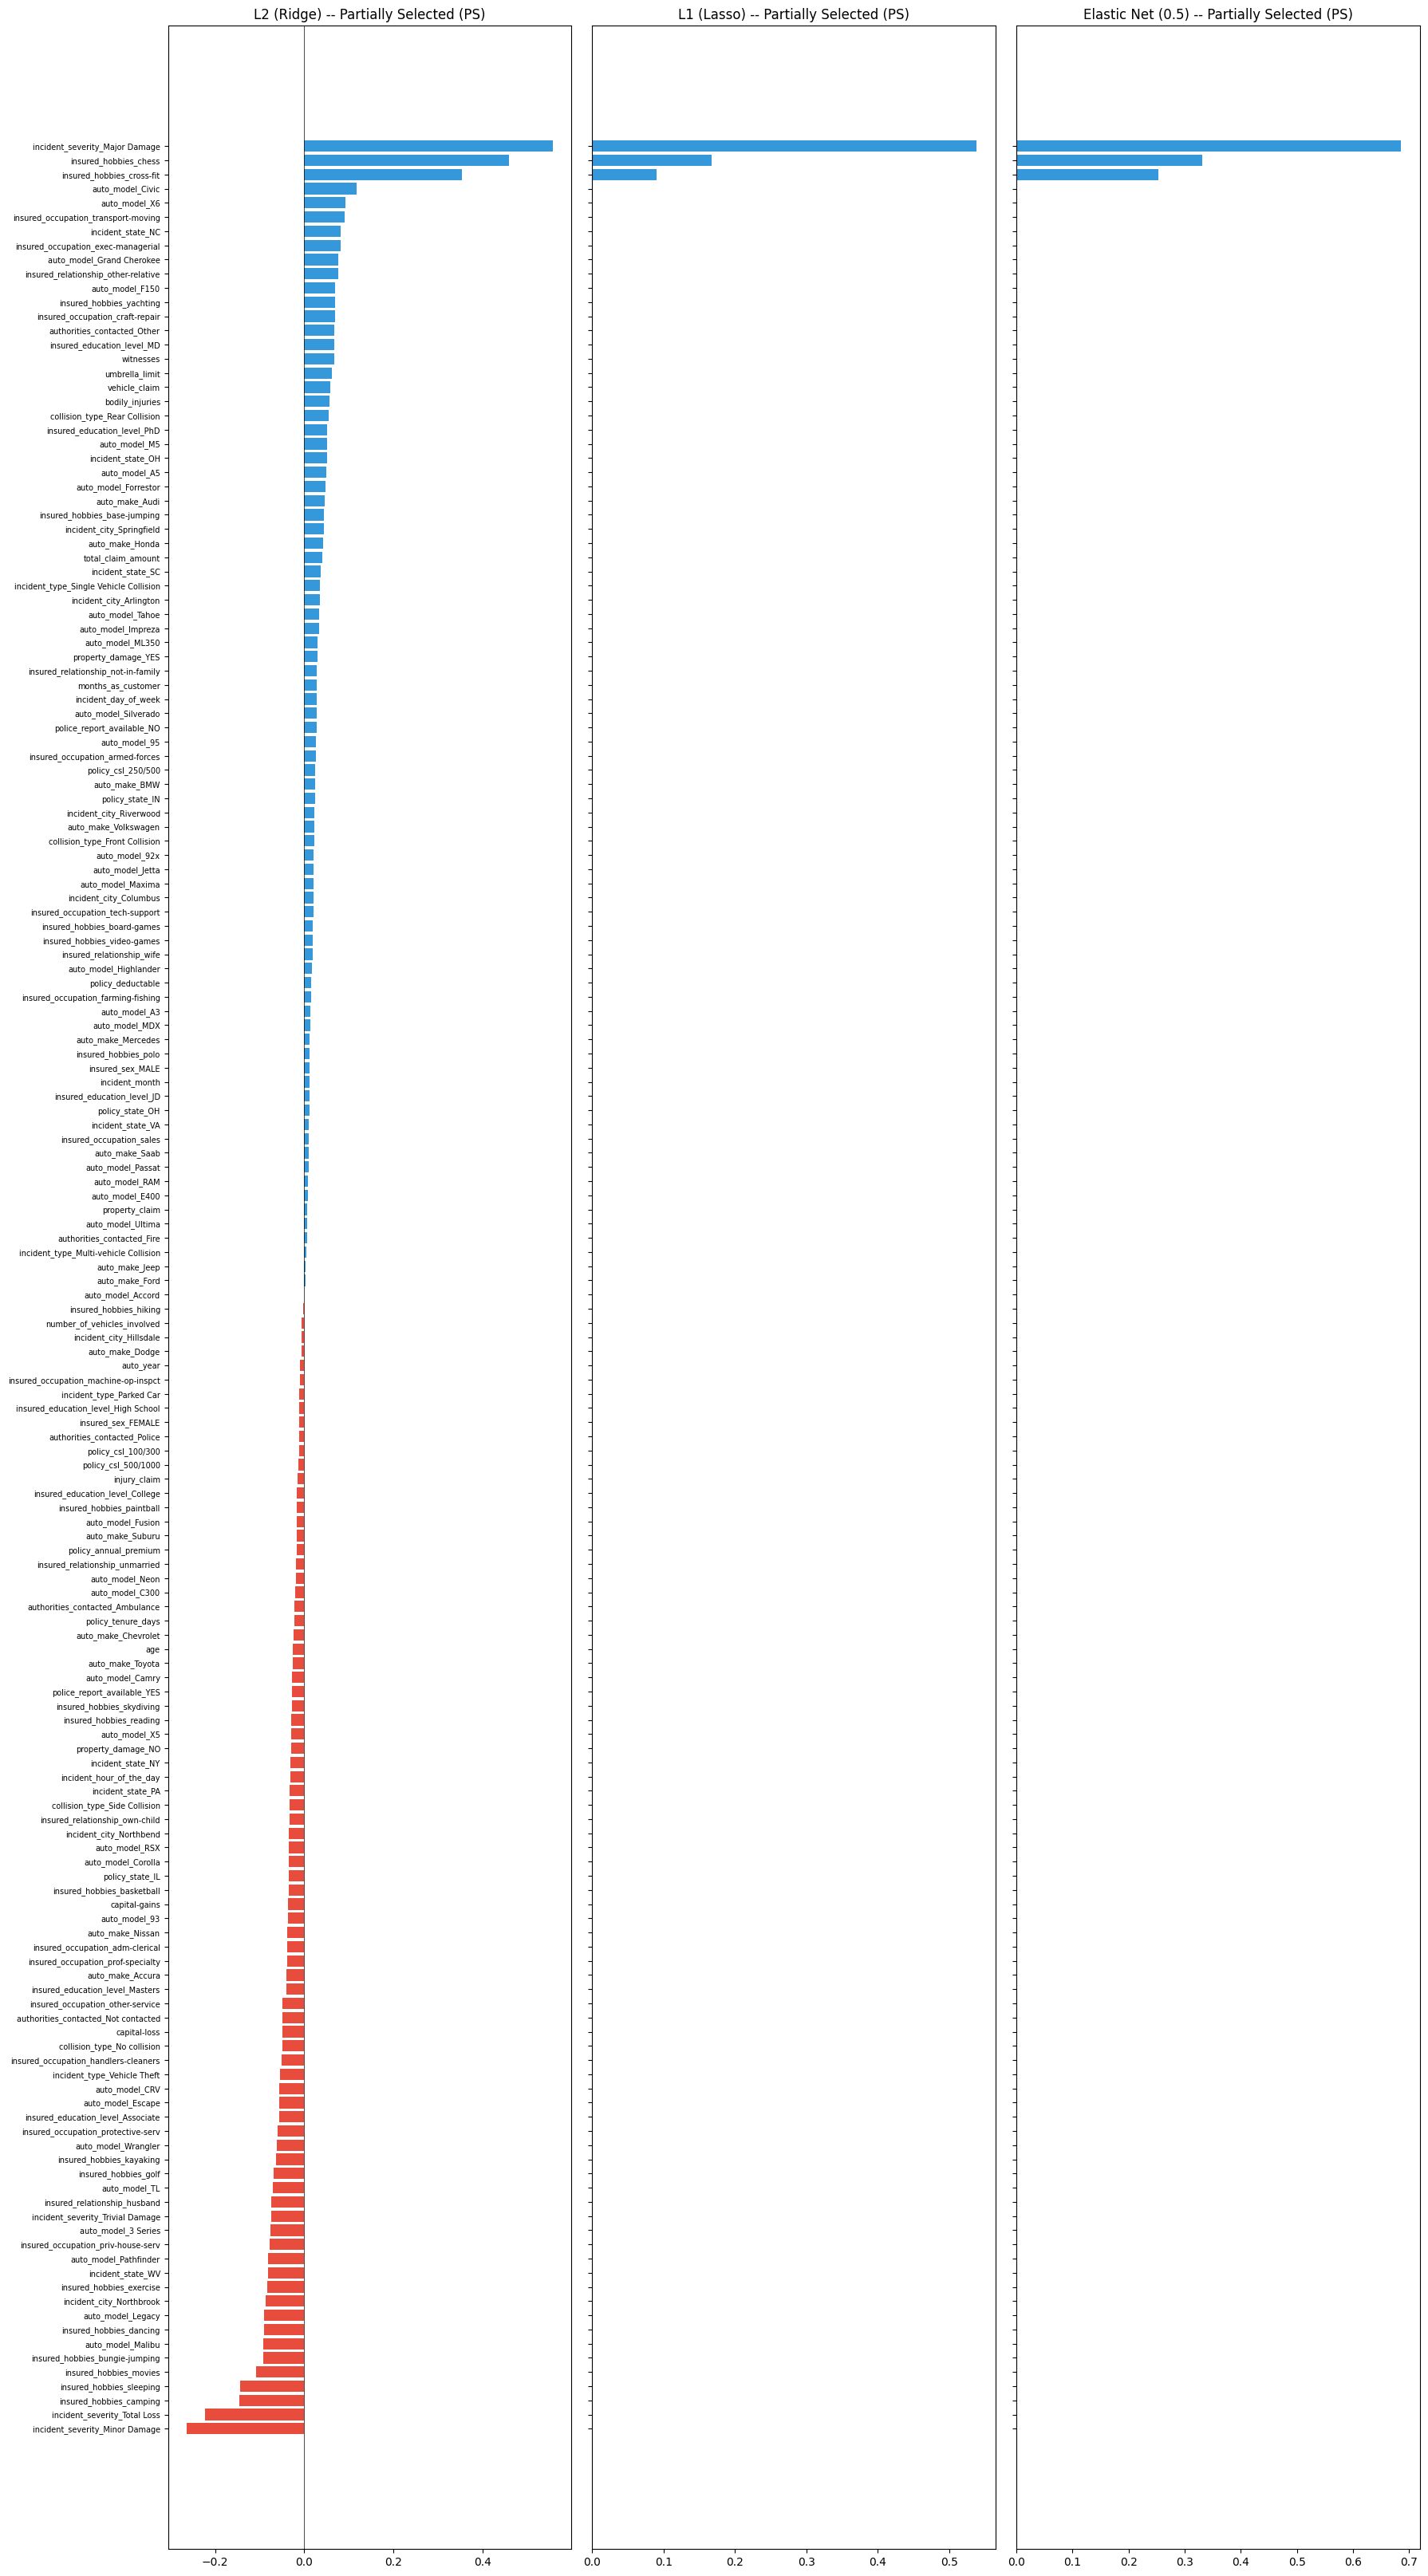


Top 15 features by |coef| -- L2 (Ridge) -- Partially Selected (PS):
  incident_severity_Major Damage                +0.5578
  insured_hobbies_chess                         +0.4579
  insured_hobbies_cross-fit                     +0.3523
  incident_severity_Minor Damage                -0.2643
  incident_severity_Total Loss                  -0.2222
  insured_hobbies_camping                       -0.1452
  insured_hobbies_sleeping                      -0.1441
  auto_model_Civic                              +0.1169
  insured_hobbies_movies                        -0.1087
  auto_model_X6                                 +0.0919
  insured_hobbies_bungie-jumping                -0.0917
  auto_model_Malibu                             -0.0914
  insured_occupation_transport-moving           +0.0911
  insured_hobbies_dancing                       -0.0904
  auto_model_Legacy                             -0.0897

Top 15 features by |coef| -- L1 (Lasso) -- Partially Selected (PS):
  incident_severity_Ma

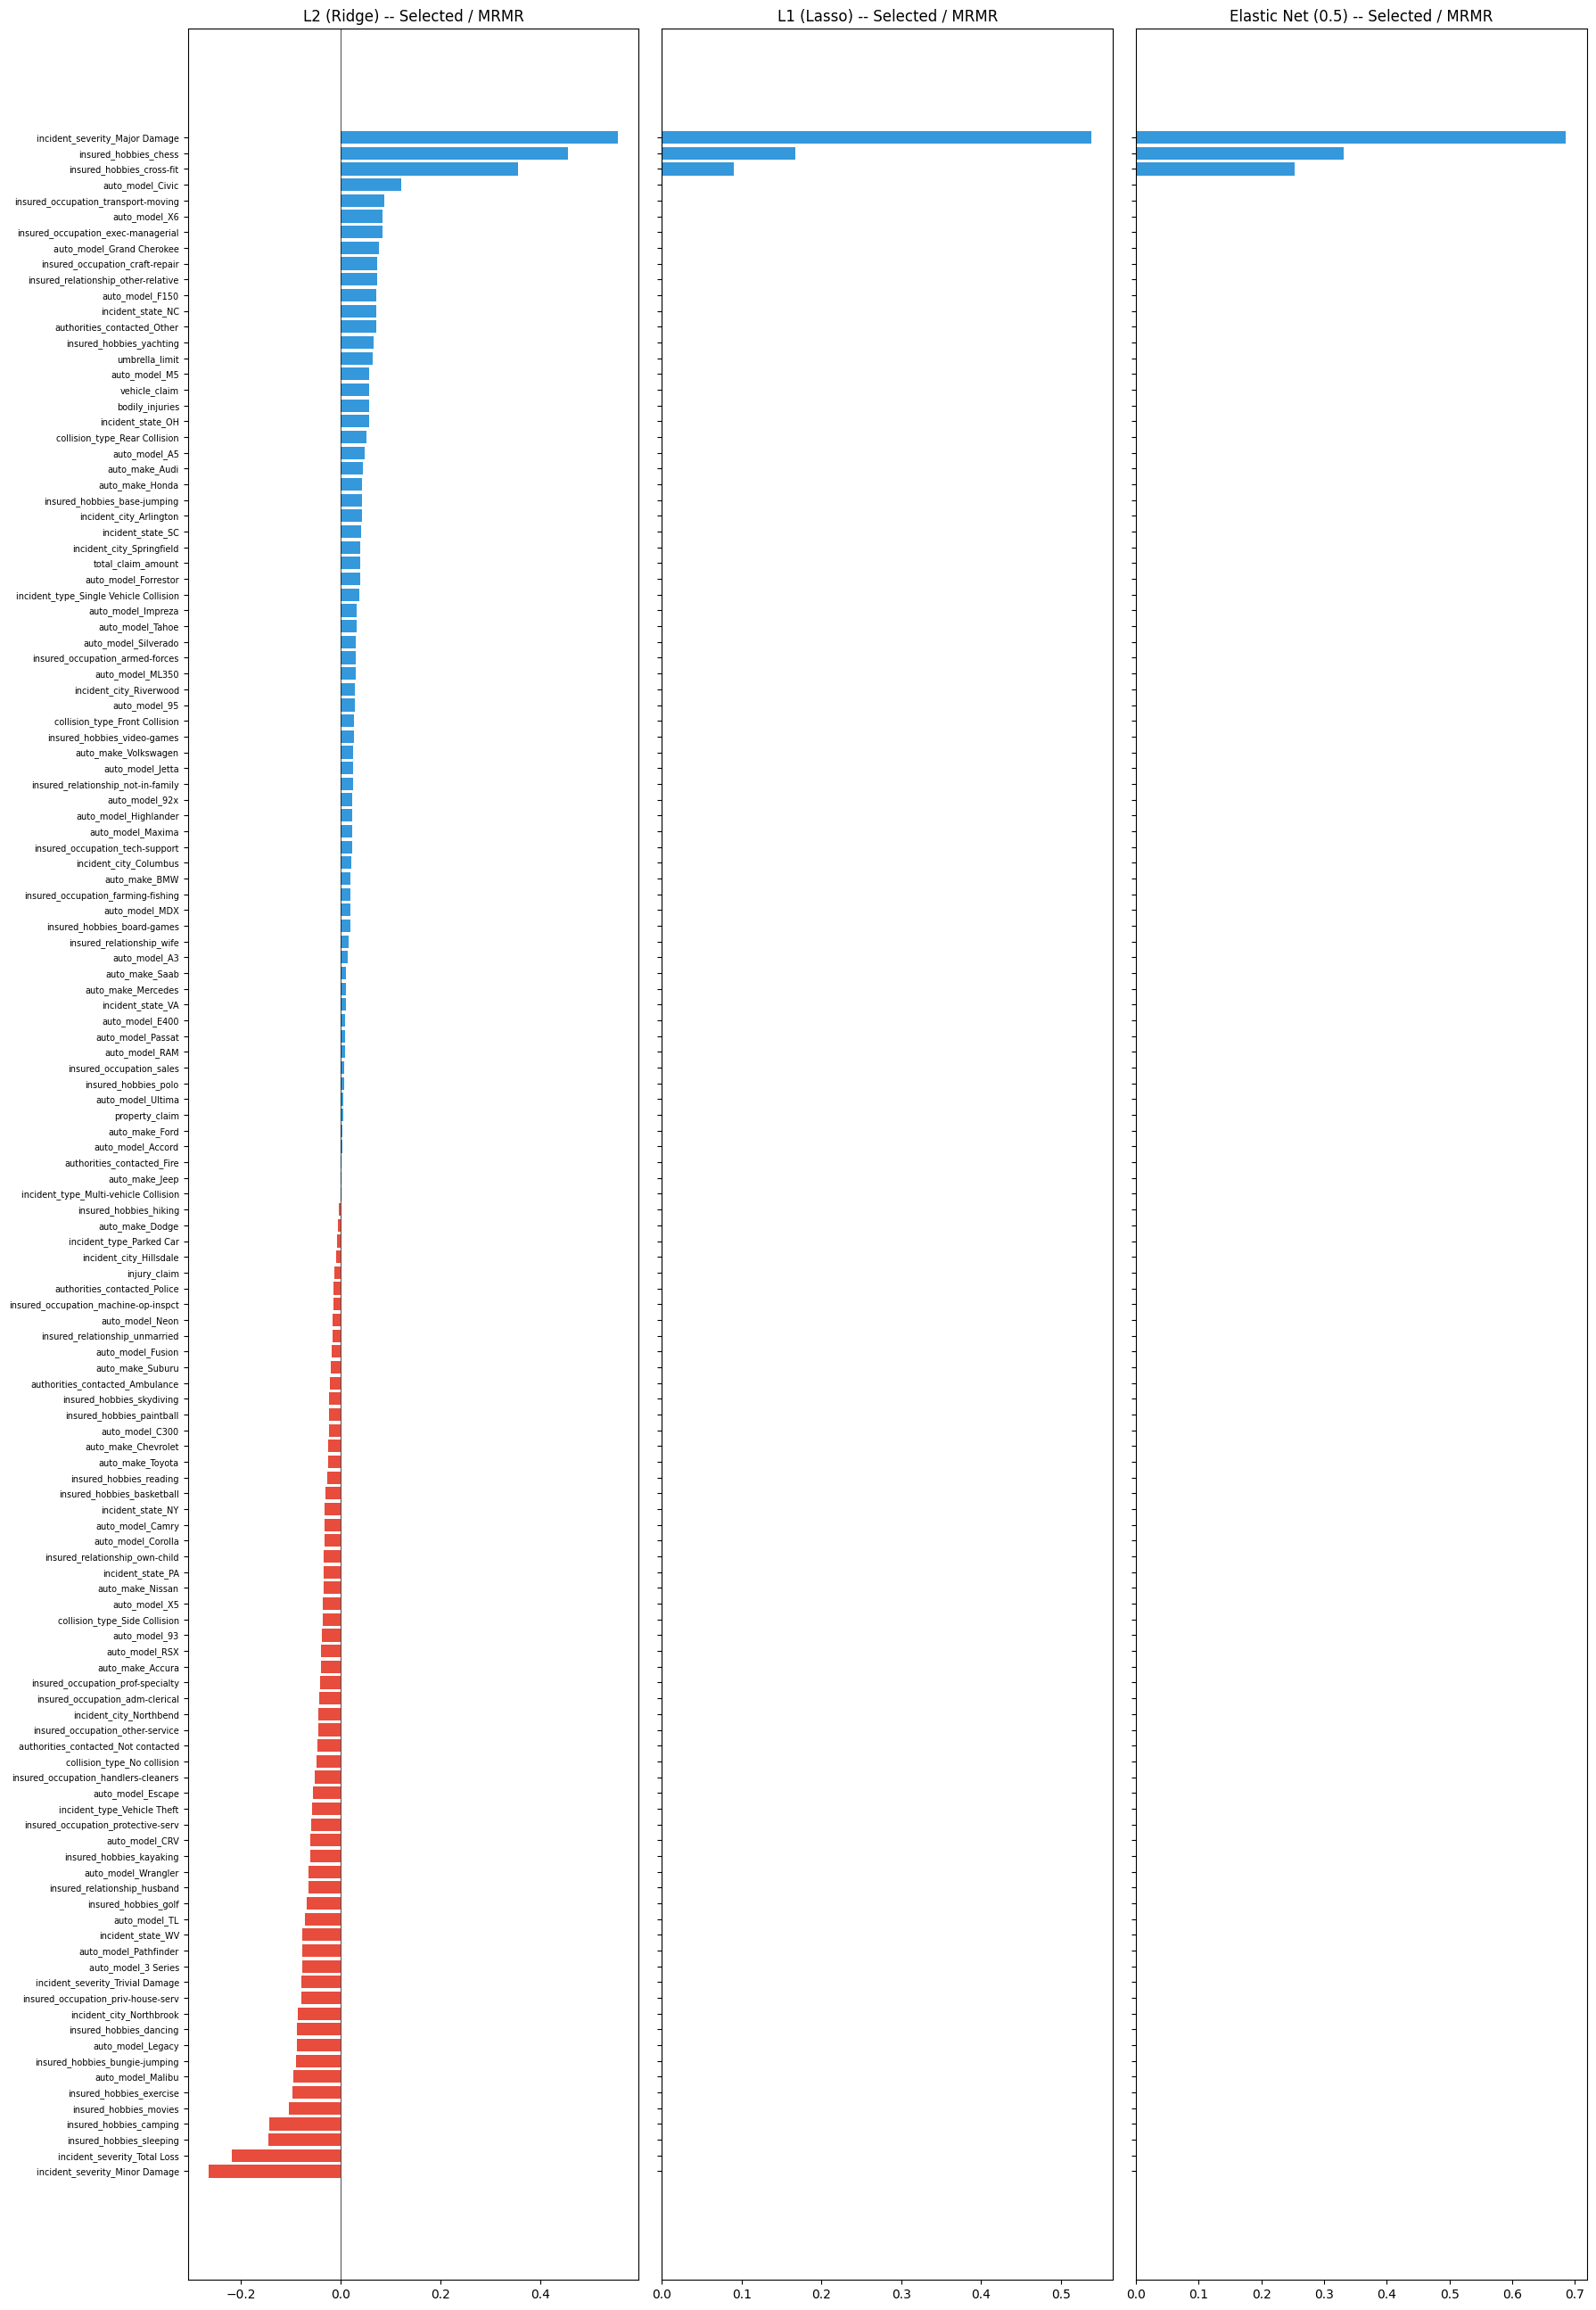


Top 15 features by |coef| -- L2 (Ridge) -- Selected / MRMR:
  incident_severity_Major Damage                +0.5569
  insured_hobbies_chess                         +0.4559
  insured_hobbies_cross-fit                     +0.3556
  incident_severity_Minor Damage                -0.2656
  incident_severity_Total Loss                  -0.2179
  insured_hobbies_sleeping                      -0.1444
  insured_hobbies_camping                       -0.1424
  auto_model_Civic                              +0.1210
  insured_hobbies_movies                        -0.1042
  insured_hobbies_exercise                      -0.0966
  auto_model_Malibu                             -0.0944
  insured_hobbies_bungie-jumping                -0.0901
  auto_model_Legacy                             -0.0880
  insured_occupation_transport-moving           +0.0875
  insured_hobbies_dancing                       -0.0871

Top 15 features by |coef| -- L1 (Lasso) -- Selected / MRMR:
  incident_severity_Major Damage      

In [14]:
for ds in datasets:
    coef_compare = pd.DataFrame({
        'Feature': ds['X_train'].columns,
        'L2 (Ridge)': ds['model_v2'].coef_[0],
        'L1 (Lasso)': ds['model_l1'].coef_[0],
        'Elastic Net': ds['model_en'].coef_[0],
    })

    fig, axes = plt.subplots(1, 3, figsize=(18, max(8, len(ds['X_train'].columns) * 0.2)), sharey=True)
    for ax, col, title in zip(axes, ['L2 (Ridge)', 'L1 (Lasso)', 'Elastic Net'],
                                      ['L2 (Ridge)', 'L1 (Lasso)', 'Elastic Net (0.5)']):
        sorted_df = coef_compare.sort_values(col)
        colors = ['#e74c3c' if v < 0 else '#3498db' for v in sorted_df[col]]
        ax.barh(sorted_df['Feature'], sorted_df[col], color=colors)
        ax.set_title(f'{title} -- {ds["label"]}')
        ax.axvline(x=0, color='black', linewidth=0.5)
        ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    plt.show()

    # Show top features by absolute coefficient
    top_n = 15
    for reg_name in ['L2 (Ridge)', 'L1 (Lasso)', 'Elastic Net']:
        top = coef_compare.reindex(coef_compare[reg_name].abs().sort_values(ascending=False).index).head(top_n)
        print(f"\nTop {top_n} features by |coef| -- {reg_name} -- {ds['label']}:")
        for _, row in top.iterrows():
            print(f"  {row['Feature']:<45} {row[reg_name]:+.4f}")

---
## Run 8: No Class Weighting (Ablation)

**Goal:** Understand the effect of `class_weight='balanced'` by removing it. This isolates
how much the class weighting contributes to fraud detection performance.

In [15]:
for ds in datasets:
    model_nw = LogisticRegression(C=ds['best_c'], penalty='l2', solver='lbfgs', max_iter=1000,
                                   class_weight=None, random_state=42)
    model_nw.fit(ds['X_train'], ds['y_train'])

    y_pred_val = predict(model_nw, ds['X_val'])
    y_prob_val = predict_proba(model_nw, ds['X_val'])
    val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)
    train_res = evaluate_model(ds['y_train'], predict(model_nw, ds['X_train']),
                               predict_proba(model_nw, ds['X_train']))

    print(f"\n{'='*60}")
    print(f"{ds['label']} -- NO class_weight (C={ds['best_c']})")
    print(f"{'='*60}")
    print_metrics(val_res, 'Validation')

    ds['results_log'].append({
        'Run': f'V7: No class_weight, C={ds["best_c"]}',
        'Train F1': train_res['f1'], 'Val F1': val_res['f1'],
        'Val Precision': val_res['precision'], 'Val Recall': val_res['recall'],
        'Val ROC AUC': val_res['roc_auc'], 'Threshold': 0.5,
    })


Partially Selected (PS) -- NO class_weight (C=0.01)
[Validation] Accuracy:  0.8067
[Validation] Precision: 0.7500
[Validation] Recall:    0.3243
[Validation] F1 Score:  0.4528
[Validation] ROC AUC:   0.8555

Selected / MRMR -- NO class_weight (C=0.01)
[Validation] Accuracy:  0.8133
[Validation] Precision: 0.8000
[Validation] Recall:    0.3243
[Validation] F1 Score:  0.4615
[Validation] ROC AUC:   0.8531


---
## Run 9: SMOTE Comparison

**Goal:** Evaluate whether SMOTE (Synthetic Minority Over-sampling Technique) improves the
best L2 configuration. SMOTE creates synthetic minority samples, changing the decision boundary
geometry differently from class_weight reweighting.

**Applied to training set only** — validation and test sets remain untouched.

In [16]:
smote = SMOTE(random_state=42)

for ds in datasets:
    print(f"\n{'='*60}")
    print(f"SMOTE Comparison -- {ds['label']}")
    print(f"{'='*60}")

    X_train_sm, y_train_sm = smote.fit_resample(ds['X_train'], ds['y_train'])
    print(f"Before SMOTE: {len(ds['y_train'])} samples (fraud: {ds['y_train'].sum()})")
    print(f"After SMOTE:  {len(y_train_sm)} samples (fraud: {y_train_sm.sum()})")

    # Train with SMOTE data but WITHOUT class_weight (SMOTE handles the imbalance)
    model_smote = LogisticRegression(C=ds['best_c'], penalty='l2', solver='lbfgs', max_iter=1000,
                                      class_weight=None, random_state=42)
    model_smote.fit(X_train_sm, y_train_sm)
    ds['model_smote'] = model_smote
    ds['X_train_smote'] = X_train_sm
    ds['y_train_smote'] = y_train_sm

    y_pred_val = predict(model_smote, ds['X_val'])
    y_prob_val = predict_proba(model_smote, ds['X_val'])
    val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)
    train_res = evaluate_model(y_train_sm, predict(model_smote, X_train_sm),
                               predict_proba(model_smote, X_train_sm))

    # Also with threshold
    y_pred_t = (y_prob_val >= ds['best_t']).astype(int)
    val_res_t = evaluate_model(ds['y_val'], y_pred_t, y_prob_val)

    print(f"\nWithout threshold (t=0.5):")
    print_metrics(val_res, 'Validation')
    print(f"\nWith threshold (t={ds['best_t']:.2f}):")
    print_metrics(val_res_t, 'Validation')

    ds['results_log'].append({
        'Run': f'V8: SMOTE + L2, C={ds["best_c"]}',
        'Train F1': train_res['f1'], 'Val F1': val_res['f1'],
        'Val Precision': val_res['precision'], 'Val Recall': val_res['recall'],
        'Val ROC AUC': val_res['roc_auc'], 'Threshold': 0.5,
    })

    ds['smote_val_res'] = val_res
    ds['smote_val_res_t'] = val_res_t


SMOTE Comparison -- Partially Selected (PS)
Before SMOTE: 700 samples (fraud: 173)
After SMOTE:  1054 samples (fraud: 527)



Without threshold (t=0.5):
[Validation] Accuracy:  0.8400
[Validation] Precision: 0.6585
[Validation] Recall:    0.7297
[Validation] F1 Score:  0.6923
[Validation] ROC AUC:   0.8570

With threshold (t=0.55):
[Validation] Accuracy:  0.8600
[Validation] Precision: 0.7105
[Validation] Recall:    0.7297
[Validation] F1 Score:  0.7200
[Validation] ROC AUC:   0.8570

SMOTE Comparison -- Selected / MRMR


Before SMOTE: 700 samples (fraud: 173)
After SMOTE:  1054 samples (fraud: 527)



Without threshold (t=0.5):
[Validation] Accuracy:  0.8467
[Validation] Precision: 0.6667
[Validation] Recall:    0.7568
[Validation] F1 Score:  0.7089
[Validation] ROC AUC:   0.8536

With threshold (t=0.55):
[Validation] Accuracy:  0.8400
[Validation] Precision: 0.6667
[Validation] Recall:    0.7027
[Validation] F1 Score:  0.6842
[Validation] ROC AUC:   0.8536


---
## Run Summary & Model Selection

Compare all experiment runs on **validation metrics only** for each feature set.
The test set has NOT been touched yet.

In [17]:
for ds in datasets:
    summary_df = pd.DataFrame(ds['results_log'])
    ds['summary_df'] = summary_df

    print(f"\n{'='*90}")
    print(f"EXPERIMENT LOG -- {ds['label']}")
    print(f"{'='*90}")
    print(summary_df.to_string(index=False))

    best_idx = summary_df['Val F1'].idxmax()
    ds['best_run'] = summary_df.loc[best_idx]
    print(f"\n>>> Best run: {summary_df.loc[best_idx, 'Run']} (Val F1 = {summary_df.loc[best_idx, 'Val F1']:.4f})")


EXPERIMENT LOG -- Partially Selected (PS)
                          Run  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC  Threshold
       V1: Baseline L2, C=1.0  0.836364 0.638889       0.657143    0.621622     0.856015       0.50
 V2: CV baseline (mean=0.601)  0.600530 0.600530            NaN         NaN          NaN       0.50
               V3: L2, C=0.01  0.786070 0.707317       0.644444    0.783784     0.859364       0.50
       V4: L2, C=0.01, t=0.55  0.806283 0.727273       0.700000    0.756757     0.859364       0.55
       V5: L1 (Lasso), C=0.01  0.705882 0.682927       0.622222    0.756757     0.827553       0.50
V6: Elastic Net (0.5), C=0.01  0.751220 0.729412       0.645833    0.837838     0.827553       0.50
  V7: No class_weight, C=0.01  0.688172 0.452830       0.750000    0.324324     0.855537       0.50
       V8: SMOTE + L2, C=0.01  0.917279 0.692308       0.658537    0.729730     0.856972       0.50

>>> Best run: V6: Elastic Net (0.5), C=0.01 (Val F1 = 0.

---
## Cross-Dataset Comparison (Validation Only)

Side-by-side comparison of the best run from each feature set on the validation set.

In [18]:
comparison_rows = []
for ds in datasets:
    best_idx = ds['summary_df']['Val F1'].idxmax()
    row = ds['summary_df'].iloc[best_idx].to_dict()
    row['Dataset'] = ds['label']
    comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)
print("\nCross-Dataset Comparison (Best Runs):")
print("=" * 100)
print(comp_df.to_string(index=False))


Cross-Dataset Comparison (Best Runs):
                          Run  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC  Threshold                 Dataset
V6: Elastic Net (0.5), C=0.01   0.75122 0.729412       0.645833    0.837838     0.827553        0.5 Partially Selected (PS)
V6: Elastic Net (0.5), C=0.01   0.75122 0.729412       0.645833    0.837838     0.827553        0.5         Selected / MRMR


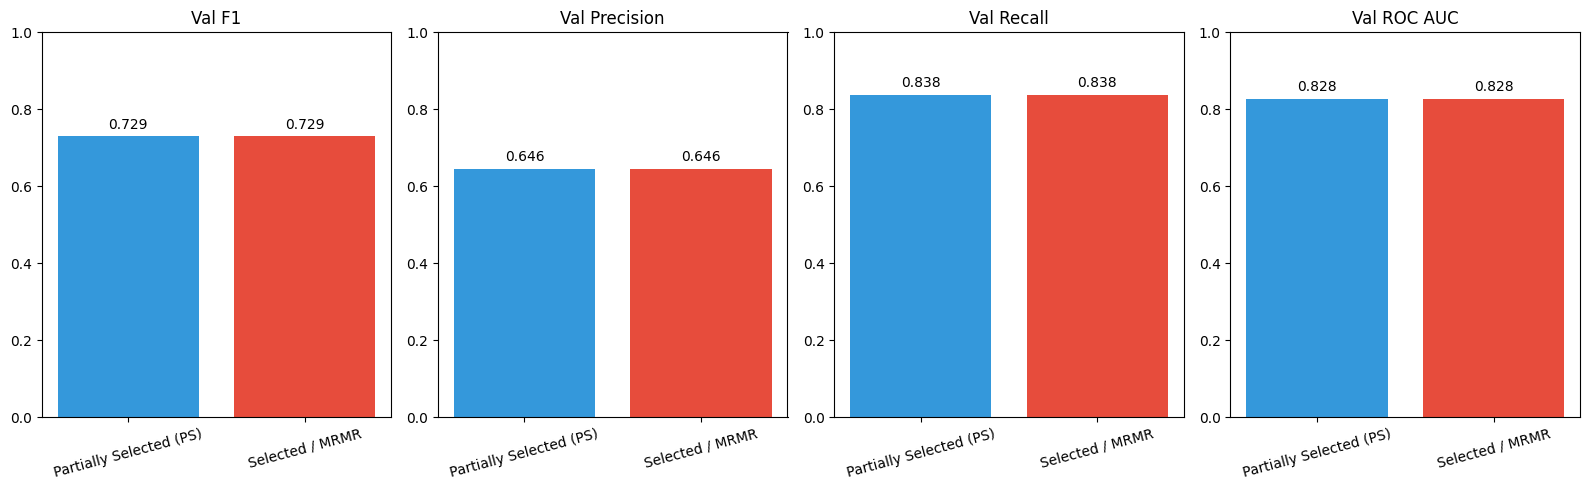

In [19]:
metrics = ['Val F1', 'Val Precision', 'Val Recall', 'Val ROC AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 5))
for ax, metric in zip(axes, metrics):
    labels = [ds['label'] for ds in datasets]
    values = [ds['best_run'][metric] for ds in datasets]
    bars = ax.bar(labels, values, color=['#3498db', '#e74c3c'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [20]:
# Determine the best overall configuration for final test
for ds in datasets:
    best_run_name = ds['best_run']['Run']
    best_t = ds['best_threshold']

    # Determine which model and whether to use SMOTE
    use_smote = 'SMOTE' in best_run_name
    if 'L1' in best_run_name:
        ds['final_model'] = ds['model_l1']
    elif 'Elastic' in best_run_name:
        ds['final_model'] = ds['model_en']
    elif use_smote:
        ds['final_model'] = ds['model_smote']
    else:
        ds['final_model'] = ds['model_v2']

    ds['use_smote'] = use_smote
    ds['final_threshold'] = best_t if 't=' in best_run_name else 0.5

    print(f"{ds['label']}: Final model = {best_run_name}, threshold = {ds['final_threshold']:.2f}, SMOTE = {use_smote}")

Partially Selected (PS): Final model = V6: Elastic Net (0.5), C=0.01, threshold = 0.50, SMOTE = False
Selected / MRMR: Final model = V6: Elastic Net (0.5), C=0.01, threshold = 0.50, SMOTE = False


---
## Final Test Evaluation (ONE-TIME)

**This is the only place in the notebook where the test set is used.**

After all hyperparameter tuning on the validation set, we evaluate the final configuration
on the held-out test set to get an unbiased estimate of real-world performance.

In [21]:
for ds in datasets:
    threshold = ds['final_threshold']
    final_model = ds['final_model']

    print(f"\n{'='*60}")
    print(f"FINAL TEST -- {ds['label']}")
    print(f"{'='*60}")
    print(f"Model: {ds['best_run']['Run']}, threshold={threshold:.2f}\n")

    y_prob_test = predict_proba(final_model, ds['X_test'])
    y_pred_test = (y_prob_test >= threshold).astype(int)
    test_res = evaluate_model(ds['y_test'], y_pred_test, y_prob_test)

    ds['test_res'] = test_res
    ds['y_prob_test'] = y_prob_test
    ds['y_pred_test'] = y_pred_test

    print_metrics(test_res, 'Test')
    print(f"\nConfusion Matrix:\n{test_res['confusion_matrix']}")
    print(f"\n{test_res['classification_report']}")


FINAL TEST -- Partially Selected (PS)
Model: V6: Elastic Net (0.5), C=0.01, threshold=0.50



[Test] Accuracy:  0.8600
[Test] Precision: 0.6538
[Test] Recall:    0.9189
[Test] F1 Score:  0.7640
[Test] ROC AUC:   0.8647

Confusion Matrix:
[[95 18]
 [ 3 34]]

              precision    recall  f1-score   support

           0       0.97      0.84      0.90       113
           1       0.65      0.92      0.76        37

    accuracy                           0.86       150
   macro avg       0.81      0.88      0.83       150
weighted avg       0.89      0.86      0.87       150


FINAL TEST -- Selected / MRMR
Model: V6: Elastic Net (0.5), C=0.01, threshold=0.50



[Test] Accuracy:  0.8600
[Test] Precision: 0.6538
[Test] Recall:    0.9189
[Test] F1 Score:  0.7640
[Test] ROC AUC:   0.8647

Confusion Matrix:
[[95 18]
 [ 3 34]]

              precision    recall  f1-score   support

           0       0.97      0.84      0.90       113
           1       0.65      0.92      0.76        37

    accuracy                           0.86       150
   macro avg       0.81      0.88      0.83       150
weighted avg       0.89      0.86      0.87       150



In [22]:
print("=" * 80)
print("FINAL TEST COMPARISON -- Partially Selected vs Selected/MRMR")
print("=" * 80)
test_comp = []
for ds in datasets:
    test_comp.append({
        'Dataset': ds['label'],
        'Best Run': ds['best_run']['Run'],
        'Threshold': ds['final_threshold'],
        'Test F1': ds['test_res']['f1'],
        'Test Precision': ds['test_res']['precision'],
        'Test Recall': ds['test_res']['recall'],
        'Test ROC AUC': ds['test_res']['roc_auc'],
    })
print(pd.DataFrame(test_comp).to_string(index=False))

FINAL TEST COMPARISON -- Partially Selected vs Selected/MRMR
                Dataset                      Best Run  Threshold  Test F1  Test Precision  Test Recall  Test ROC AUC
Partially Selected (PS) V6: Elastic Net (0.5), C=0.01        0.5 0.764045        0.653846     0.918919      0.864745
        Selected / MRMR V6: Elastic Net (0.5), C=0.01        0.5 0.764045        0.653846     0.918919      0.864745


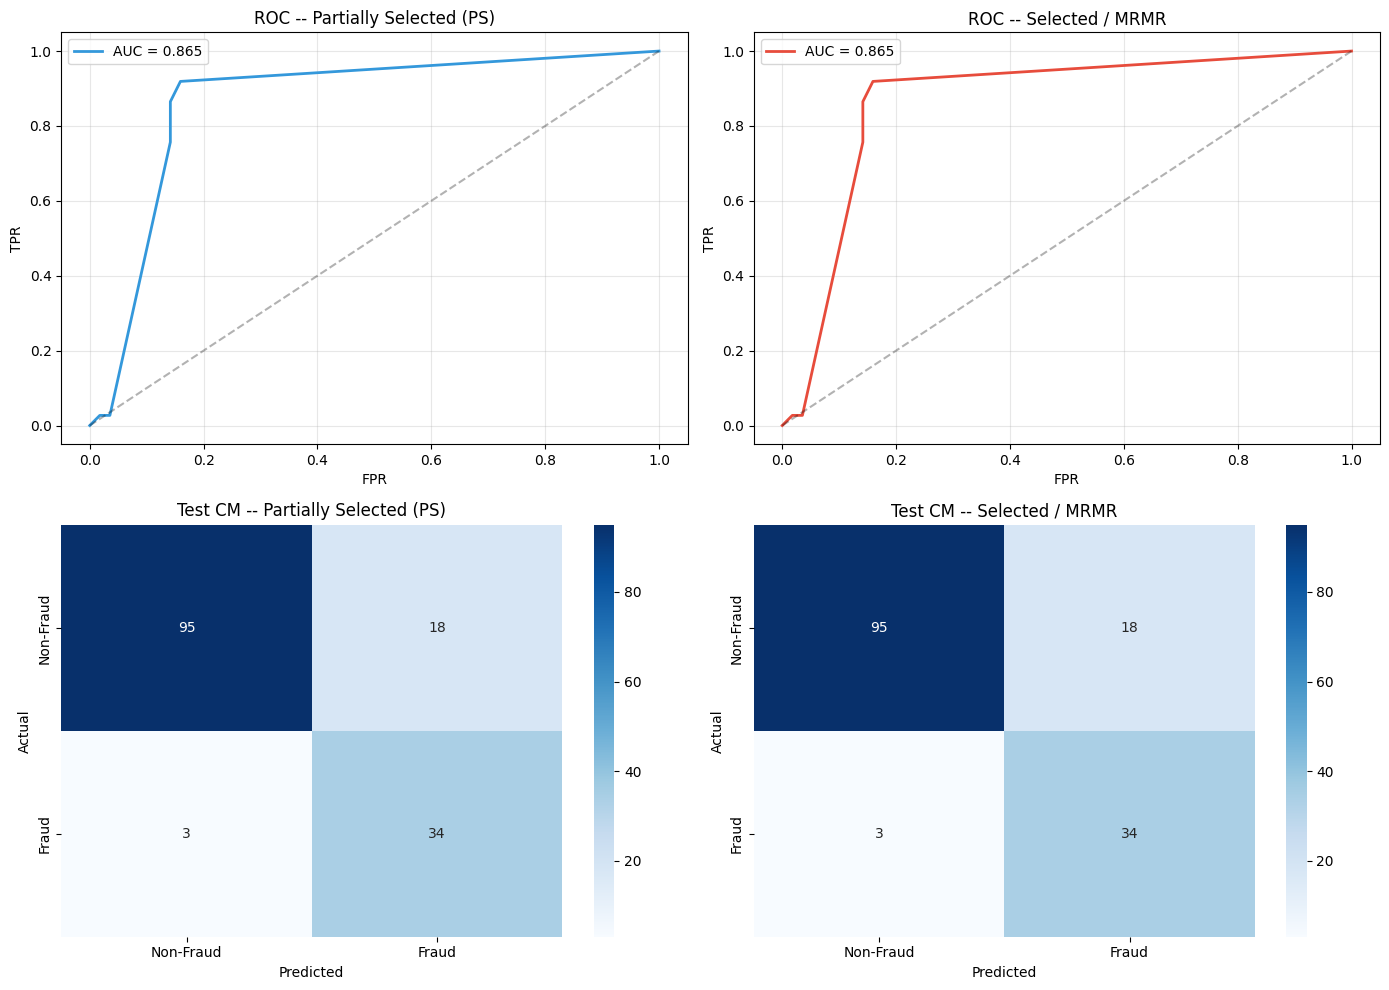

In [23]:
n_ds = len(datasets)
fig, axes = plt.subplots(2, max(n_ds, 2), figsize=(7*max(n_ds, 2), 10))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, ds in enumerate(datasets):
    # ROC Curve
    fpr, tpr, _ = roc_curve(ds['y_test'], ds['y_prob_test'])
    roc_auc_val = auc(fpr, tpr)
    axes[0, i].plot(fpr, tpr, color=colors[i], linewidth=2, label=f'AUC = {roc_auc_val:.3f}')
    axes[0, i].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0, i].set_title(f'ROC -- {ds["label"]}')
    axes[0, i].set_xlabel('FPR')
    axes[0, i].set_ylabel('TPR')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    # Confusion Matrix
    cm = confusion_matrix(ds['y_test'], ds['y_pred_test'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, i],
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    axes[1, i].set_title(f'Test CM -- {ds["label"]}')
    axes[1, i].set_ylabel('Actual')
    axes[1, i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

---
## Save Best Model

Save the best model (across both feature sets) and its metadata using joblib.
The metadata includes the feature columns, scaler, and threshold needed for inference.

In [24]:
# Determine best model across both feature sets by test F1
best_ds = max(datasets, key=lambda d: d['test_res']['f1'])

print(f"Best overall model: {best_ds['label']}")
print(f"  Run: {best_ds['best_run']['Run']}")
print(f"  Test F1: {best_ds['test_res']['f1']:.4f}")
print(f"  Test ROC AUC: {best_ds['test_res']['roc_auc']:.4f}")

os.makedirs('../models', exist_ok=True)

save_data = {
    'model': best_ds['final_model'],
    'scaler': best_ds['scaler'],
    'feature_columns': best_ds['train_cols'],
    'threshold': best_ds['final_threshold'],
    'dataset': best_ds['label'],
    'best_run': best_ds['best_run']['Run'],
    'test_metrics': {
        'f1': best_ds['test_res']['f1'],
        'precision': best_ds['test_res']['precision'],
        'recall': best_ds['test_res']['recall'],
        'roc_auc': best_ds['test_res']['roc_auc'],
    },
}

joblib.dump(save_data, '../models/logistic_regression.joblib')
print(f"\nSaved to ../models/logistic_regression.joblib")
print(f"Keys: {list(save_data.keys())}")

Best overall model: Partially Selected (PS)
  Run: V6: Elastic Net (0.5), C=0.01
  Test F1: 0.7640
  Test ROC AUC: 0.8647

Saved to ../models/logistic_regression.joblib
Keys: ['model', 'scaler', 'feature_columns', 'threshold', 'dataset', 'best_run', 'test_metrics']
